  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo   

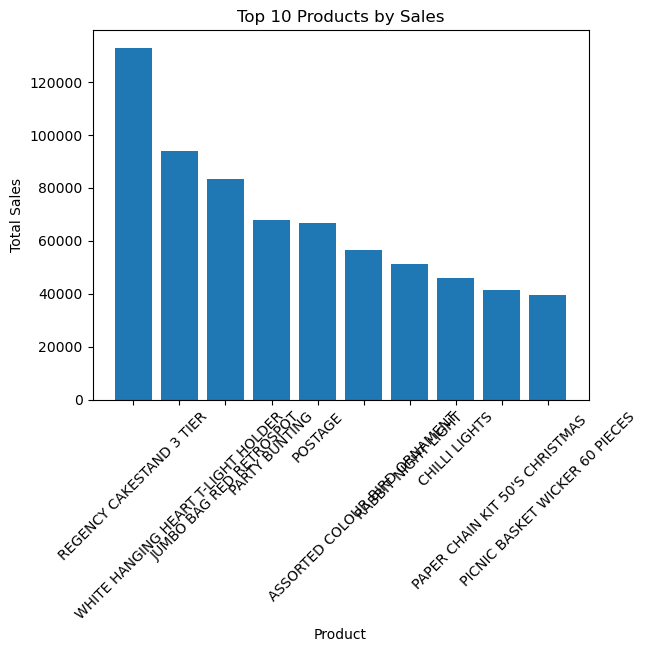

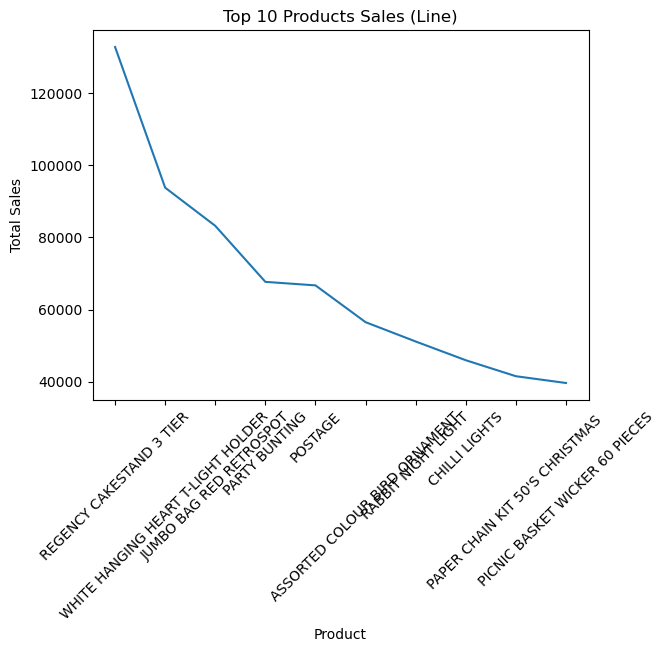

In [1]:
# ==========================================
# SCENARIO 1: E-commerce Sales Data
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("data.csv", encoding="latin1")

# Inspect data
print(df.head())
print(df.info())
print(df.describe())

# Check missing values
print(df.isnull().sum())

# Remove missing values
df.dropna(inplace=True)

# Create Sales column
df["Sales"] = df["Quantity"] * df["UnitPrice"]

# Group by product
sales_per_product = (
    df.groupby("Description")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

top10 = sales_per_product.head(10)
print(top10)

# Bar Chart
plt.figure()
plt.bar(top10.index, top10.values)
plt.xticks(rotation=45)
plt.title("Top 10 Products by Sales")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.show()

# Line Chart
plt.figure()
plt.plot(top10.index, top10.values)
plt.xticks(rotation=45)
plt.title("Top 10 Products Sales (Line)")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.show()

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768

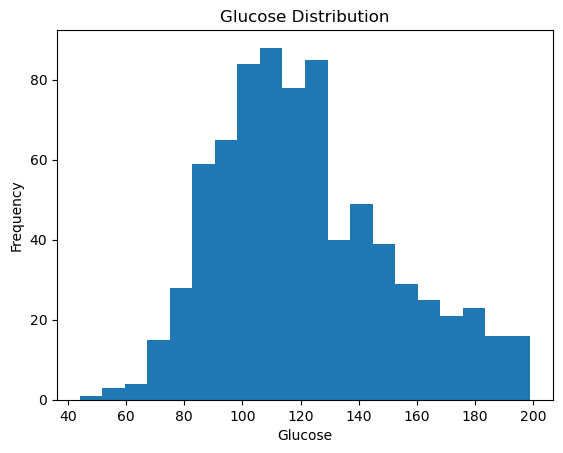

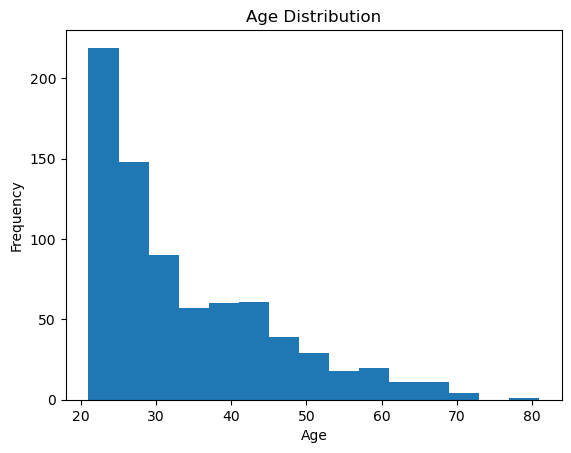

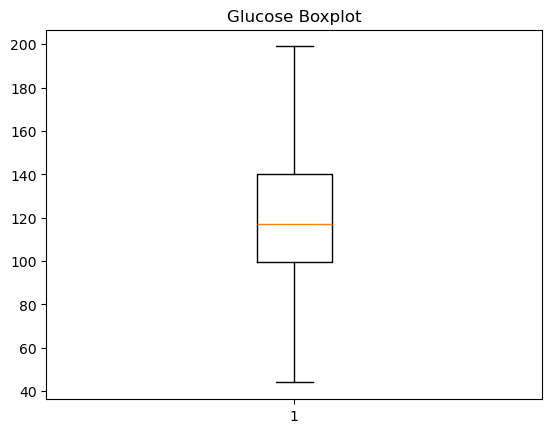

Outcome
0    110.682000
1    142.130597
Name: Glucose, dtype: float64


In [2]:
# ==========================================
# SCENARIO 2: Hospital Patient Records
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("diabetes.csv")

print(df.head())
print(df.info())
print(df.describe())

# Check missing values
print(df.isnull().sum())
print((df == 0).sum())

# Replace invalid zeros
cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df[cols] = df[cols].replace(0, np.nan)

# Fill missing values
df.fillna(df.median(), inplace=True)

# Glucose Histogram
plt.figure()
plt.hist(df["Glucose"], bins=20)
plt.title("Glucose Distribution")
plt.xlabel("Glucose")
plt.ylabel("Frequency")
plt.show()

# Age Histogram
plt.figure()
plt.hist(df["Age"], bins=15)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# Boxplot
plt.figure()
plt.boxplot(df["Glucose"])
plt.title("Glucose Boxplot")
plt.show()

# Pattern analysis
print(df.groupby("Outcome")["Glucose"].mean())

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 colu

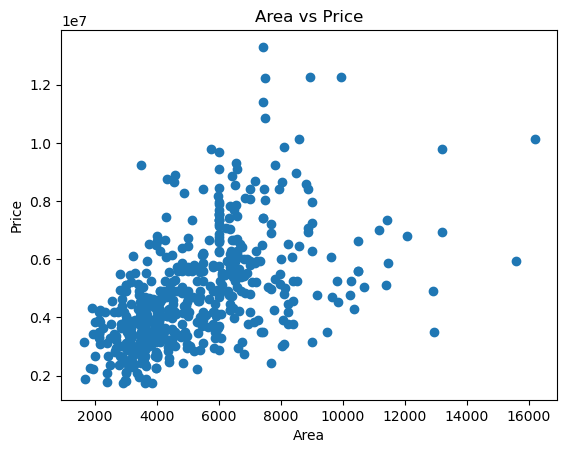

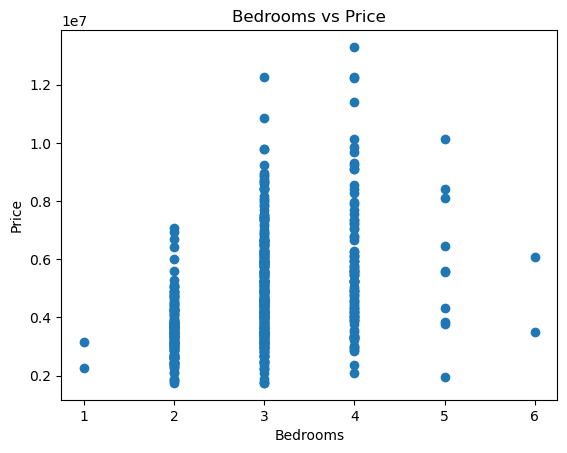

              price      area  bedrooms  bathrooms   stories   parking
price      1.000000  0.535997  0.366494   0.517545  0.420712  0.384394
area       0.535997  1.000000  0.151858   0.193820  0.083996  0.352980
bedrooms   0.366494  0.151858  1.000000   0.373930  0.408564  0.139270
bathrooms  0.517545  0.193820  0.373930   1.000000  0.326165  0.177496
stories    0.420712  0.083996  0.408564   0.326165  1.000000  0.045547
parking    0.384394  0.352980  0.139270   0.177496  0.045547  1.000000


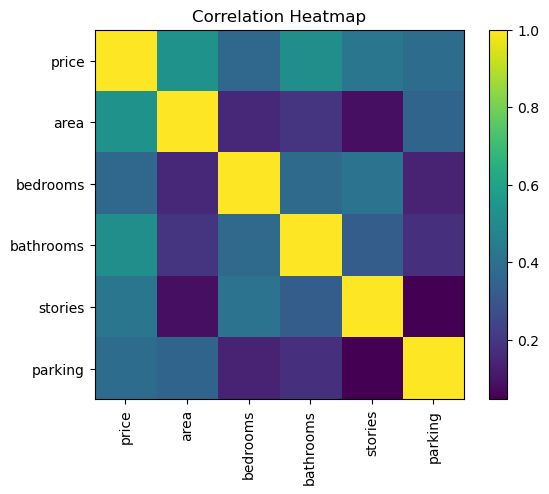

In [3]:
# ==========================================
# SCENARIO 3: Housing Dataset
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("housing.csv")

print(df.head())
print(df.info())
print(df.describe())

# Missing values
print(df.isnull().sum())

# Fill numeric missing values
df.fillna(df.median(numeric_only=True), inplace=True)

# Scatter Plot (Area vs Price)
plt.figure()
plt.scatter(df["area"], df["price"])
plt.title("Area vs Price")
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()

# Scatter Plot (Bedrooms vs Price)
plt.figure()
plt.scatter(df["bedrooms"], df["price"])
plt.title("Bedrooms vs Price")
plt.xlabel("Bedrooms")
plt.ylabel("Price")
plt.show()

# Correlation Matrix
corr = df.corr(numeric_only=True)
print(corr)

# Heatmap using matplotlib
plt.figure()
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.show()

     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  04-09-2012       58       635  ...                  7             0   
1  08-03-2014       38        11  ...                  5             0   
2  21-08-2013       26       426  ...                  4             0   
3  10-02-2014       26        11  ...                  6             0   
4  19-01-2014       94       173  ...                  5             0   

   AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  AcceptedCmp2  Complain  \
0             0

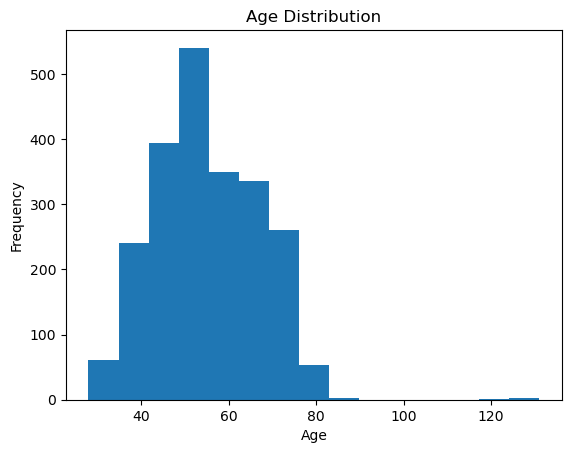

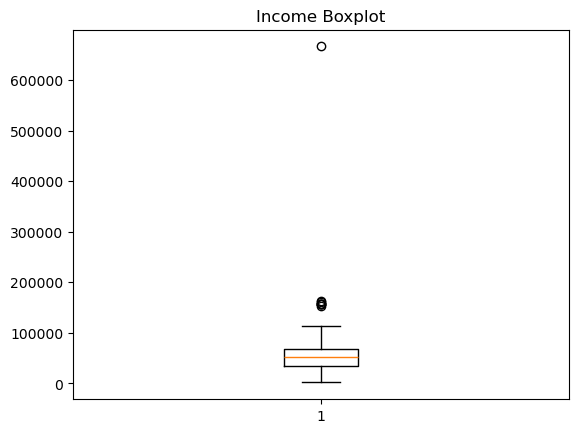

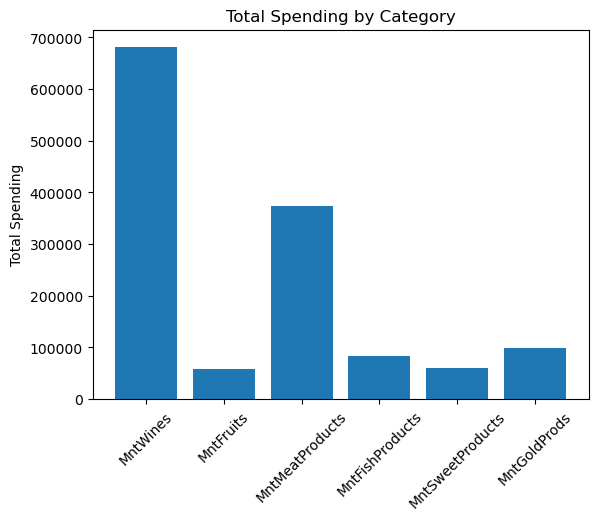

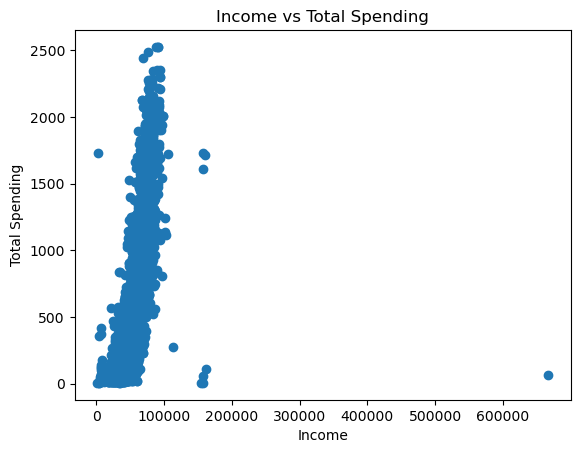

In [4]:
# ==========================================
# SCENARIO 4: Banking Customer Data
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("marketing_campaign.csv", sep="\t")

print(df.head())
print(df.info())
print(df.describe())

# Missing values
print(df.isnull().sum())

# Create Age column
df["Age"] = 2024 - df["Year_Birth"]

# Age Histogram
plt.figure()
plt.hist(df["Age"], bins=15)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# Income Boxplot
plt.figure()
plt.boxplot(df["Income"].dropna())
plt.title("Income Boxplot")
plt.show()

# Spending Pattern
spending_cols = [
    "MntWines", "MntFruits", "MntMeatProducts",
    "MntFishProducts", "MntSweetProducts", "MntGoldProds"
]

total_spending = df[spending_cols].sum()

plt.figure()
plt.bar(total_spending.index, total_spending.values)
plt.xticks(rotation=45)
plt.title("Total Spending by Category")
plt.ylabel("Total Spending")
plt.show()

# Income vs Spending
df["TotalSpending"] = df[spending_cols].sum(axis=1)

plt.figure()
plt.scatter(df["Income"], df["TotalSpending"])
plt.title("Income vs Total Spending")
plt.xlabel("Income")
plt.ylabel("Total Spending")
plt.show()